In [3]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Charger les données Silver
df = pd.read_csv("../data/silver/online_retail_clean.csv")

In [5]:
#Vérifier les données
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
#Informations dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392692 non-null  int64  
 1   StockCode    392692 non-null  object 
 2   Description  392692 non-null  object 
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  object 
 5   UnitPrice    392692 non-null  float64
 6   CustomerID   392692 non-null  float64
 7   Country      392692 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 24.0+ MB


In [7]:
#Vérifier les nulls
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [8]:
#Convertir la date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [9]:
#Snapshot Date
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


In [10]:
#Créer TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [11]:
#Créer Snapshot Date
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


In [12]:
#Calcul RFM
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

In [13]:
#Renommer les colonnes
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

In [14]:
# Remettre CustomerID comme colonne

rfm = rfm.reset_index()

In [31]:
# Vérification

print(rfm.head())

print(rfm.columns)

   CustomerID  Recency  Frequency  Monetary R_score F_score M_score RFM_Score  \
0     12346.0      326          1  77183.60       1       1       5       115   
1     12347.0        2          7   4310.00       5       5       5       555   
2     12348.0       75          4   1797.24       2       4       4       244   
3     12349.0       19          1   1757.55       4       1       4       414   
4     12350.0      310          1    334.40       1       1       2       112   

            Segment       CLV  
0           At Risk  77183.60  
1         Champions  30170.00  
2   Loyal Customers   7188.96  
3  Recent Customers   1757.55  
4           At Risk    334.40  
Index(['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score',
       'M_score', 'RFM_Score', 'Segment', 'CLV'],
      dtype='object')


In [15]:
#Afficher le résultat
rfm.head()


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [16]:
#Vérifier les statistiques RFM
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


In [17]:
#Scoring RFM


#Recency Score:
rfm['R_score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

#Frequency Score:
rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

#Monetary Score:
rfm['M_score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)


In [18]:
#Créer le score RFM
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

In [19]:
#Segmentation Clients
def segment_customer(row):

    if row['R_score'] >= 4 and row['F_score'] >= 4:
        return 'Champions'

    elif row['F_score'] >= 4:
        return 'Loyal Customers'

    elif row['R_score'] >= 4:
        return 'Recent Customers'

    elif row['R_score'] <= 2:
        return 'At Risk'

    else:
        return 'Potential Loyalist'

In [20]:
#Appliquer la segmentation
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [21]:
#Voir les segments
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
0,12346.0,326,1,77183.60,1,1,5,115,At Risk
1,12347.0,2,7,4310.00,5,5,5,555,Champions
2,12348.0,75,4,1797.24,2,4,4,244,Loyal Customers
3,12349.0,19,1,1757.55,4,1,4,414,Recent Customers
4,12350.0,310,1,334.40,1,1,2,112,At Risk


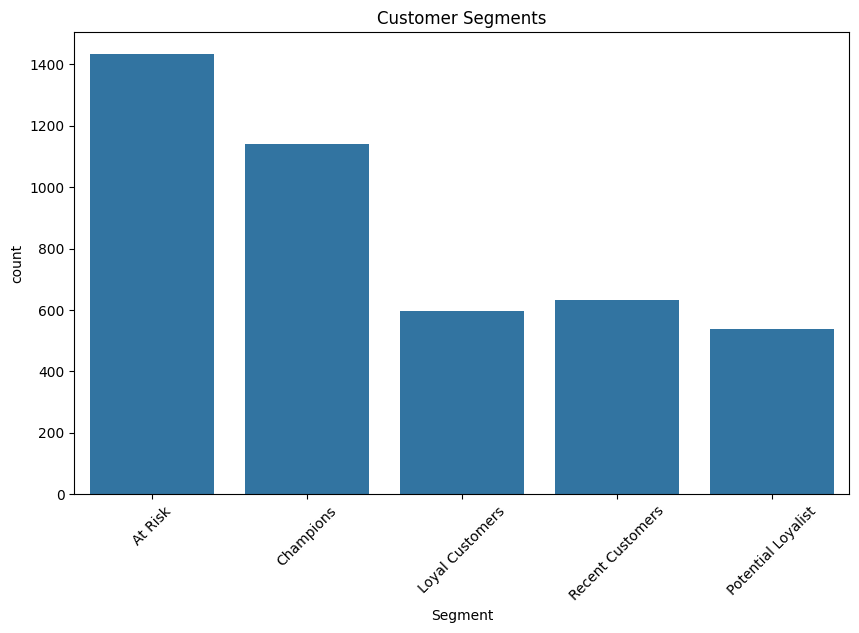

In [22]:
#Visualisation segments
plt.figure(figsize=(10,6))

sns.countplot(
    data=rfm,
    x='Segment'
)

plt.xticks(rotation=45)

plt.title("Customer Segments")

plt.show()

In [23]:
#Calcul CLV simple
rfm['CLV'] = (
    rfm['Monetary'] *
    rfm['Frequency']
)

In [24]:
#Top clients
top_customers = rfm.sort_values(
    by='CLV',
    ascending=False
)

top_customers.head(10)

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,CLV
1879,14911.0,1,201,143711.17,5,5,5,555,Champions,28885945.17
1689,14646.0,2,73,280206.02,5,5,5,555,Champions,20455039.46
4201,18102.0,1,60,259657.30,5,5,5,555,Champions,15579438.00
3728,17450.0,8,46,194390.79,5,5,5,555,Champions,8941976.34
326,12748.0,1,209,33053.19,5,5,5,555,Champions,6908116.71
1333,14156.0,10,55,117210.08,5,5,5,555,Champions,6446554.40
562,13089.0,3,97,58762.08,5,5,5,555,Champions,5699921.76
2176,15311.0,1,91,60632.75,5,5,5,555,Champions,5517580.25
2702,16029.0,39,63,80850.84,3,5,5,355,Loyal Customers,5093602.92
4010,17841.0,2,124,40519.84,5,5,5,555,Champions,5024460.16


In [25]:
#dosssier gold creation
import os

os.makedirs("../data/gold", exist_ok=True)

print("Dossier gold créé")

Dossier gold créé


In [26]:
#Export RFM
rfm.to_csv(
    "../data/gold/rfm_customers.csv",
    index=False
)

In [27]:
#Export CLV
top_customers.to_csv(
    "../data/gold/clv_customers.csv",
    index=False
)

In [28]:
# Création des KPIs business
kpis = pd.DataFrame({

    'Total_Revenue': [df['TotalPrice'].sum()],

    'Average_Order_Value': [df['TotalPrice'].mean()],

    'Total_Customers': [df['CustomerID'].nunique()]
})

In [29]:
# Export KPI Dataset
kpis.to_csv(
    "../data/gold/kpi_sales.csv",
    index=False
)

In [30]:
# Final Verification

print("L3 completed successfully")

L3 completed successfully
